In [ ]:
!pip install -q torch transformers pandas matplotlib sentence-transformers faiss-cpu scikit-learn

In [ ]:
import re
import math
import faiss
import torch
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from IPython.display import display
from sklearn.metrics import accuracy_score
from sentence_transformers import SentenceTransformer, CrossEncoder
from transformers import AutoTokenizer, AutoModel, AutoModelForSequenceClassification

camel_name = "CAMeL-Lab/bert-base-arabic-camelbert-mix"

tokenizer = AutoTokenizer.from_pretrained(camel_name)

classifier_model = AutoModelForSequenceClassification.from_pretrained(
    camel_name,
    num_labels=5
).eval()

attention_model = AutoModel.from_pretrained(
    camel_name,
    output_attentions=True
).eval()

embed_model = SentenceTransformer(
    "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
)

reranker = CrossEncoder(
    "cross-encoder/mmarco-mMiniLMv2-L12-H384-v1",
    device="cpu"
)

unk_token = tokenizer.unk_token


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: CAMeL-Lab/bert-base-arabic-camelbert-mix
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSIN

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: CAMeL-Lab/bert-base-arabic-camelbert-mix
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [ ]:
def normalize_spaces(text):
    return re.sub(r"\s+", " ", str(text)).strip()

def normalize_arabic(text):
    text = re.sub(r"[إأآا]", "ا", text)
    text = re.sub(r"ى", "ي", text)
    text = re.sub(r"ة", "ه", text)
    return text

def mask_pii(text):
    text = re.sub(r'\S+@\S+', '[EMAIL]', text)
    text = re.sub(r'05\d{8}', '[PHONE]', text)
    return text

In [ ]:
def tokenize_text(text):
    return tokenizer.tokenize(text)

def calculate_fertility(token_count, word_count):
    return token_count / word_count if word_count else 0

def calculate_unk_rate(tokens):
    return tokens.count(unk_token) / len(tokens) if len(tokens) else 0

def detect_dialect(text):
    saudi_words = ["وش", "شلون", "علومك", "وش اخبارك"]
    return "Saudi Dialect" if any(w in text for w in saudi_words) else "MSA"

def detect_clitics(words):
    return [w for w in words if w.startswith(("و","ب","ل","ف")) and len(w) > 4]

In [ ]:
def attention(q, k, v, mask=None):
    d_k = q.size(-1)
    scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(d_k)
    if mask is not None:
        scores = scores.masked_fill(~mask, torch.finfo(scores.dtype).min)
    weights = torch.softmax(scores, dim=-1)
    return torch.matmul(weights, v), weights

In [ ]:
topic_names = [
    "hr_issue",
    "it_issue",
    "finance_issue",
    "operations_issue",
    "management_issue"
]

tasks = pd.DataFrame(columns=[
    "task","clean_text","normalized_text","masked_text","tokens",
    "token_count","word_count","fertility","unk_rate","priority_score",
    "topic_label","topic_name","dialect","clitics"
])

task_embeddings = []
faiss_index = None
errors_log = []

In [ ]:
def add_task(task_text):
    global tasks, faiss_index, task_embeddings

    clean = normalize_spaces(task_text)
    normalized = normalize_arabic(clean)
    masked = mask_pii(normalized)
    tokens = tokenize_text(masked)

    token_count = len(tokens)
    word_count = len(masked.split())
    fertility = calculate_fertility(token_count, word_count)
    unk_rate = calculate_unk_rate(tokens)
    dialect = detect_dialect(masked)
    clitics = detect_clitics(masked.split())

    enc_att = tokenizer(masked, return_tensors="pt", padding="max_length", max_length=24)
    with torch.inference_mode():
        att = attention_model(**enc_att).attentions
    priority_score = float(att[8][0,3].mean())

    enc_cls = tokenizer(masked, return_tensors="pt", truncation=True, padding=True)
    with torch.inference_mode():
        logits = classifier_model(**enc_cls).logits
    label_id = int(torch.argmax(logits))
    label_name = topic_names[label_id]

    emb = embed_model.encode([masked])[0]
    task_embeddings.append(emb)

    if faiss_index is None:
        faiss_index = faiss.IndexFlatL2(len(emb))
    faiss_index.add(np.array(task_embeddings).astype("float32"))

    new_row = {
        "task": task_text,
        "clean_text": clean,
        "normalized_text": normalized,
        "masked_text": masked,
        "tokens": tokens,
        "token_count": token_count,
        "word_count": word_count,
        "fertility": fertility,
        "unk_rate": unk_rate,
        "priority_score": priority_score,
        "topic_label": label_id,
        "topic_name": label_name,
        "dialect": dialect,
        "clitics": clitics
    }

    tasks.loc[len(tasks)] = new_row
    print("✔️ تمت إضافة المهمة")

In [ ]:
def show_tasks():
    display(tasks)

def dashboard():
    plt.figure(figsize=(8,5))
    plt.hist(tasks["priority_score"], bins=10, color="orange")
    plt.title("توزيع أولوية المهام")
    plt.show()

    plt.figure(figsize=(8,5))
    plt.hist(tasks["token_count"], bins=10, color="purple")
    plt.title("توزيع عدد التوكنز")
    plt.show()

    plt.figure(figsize=(8,5))
    tasks["topic_name"].value_counts().plot(kind="bar", color="teal")
    plt.title("عدد المهام حسب نوع المشكلة")
    plt.show()

In [ ]:
def analyze_task_attention(i):
    text = tasks.iloc[i]["masked_text"]
    enc = tokenizer(text, return_tensors="pt", padding="max_length", max_length=24)
    with torch.inference_mode():
        att = attention_model(**enc).attentions
    weights = att[8][0,3]
    tokens_list = tokenizer.convert_ids_to_tokens(enc.input_ids[0])

    plt.figure(figsize=(8,6))
    plt.imshow(weights.detach().numpy())
    plt.xticks(range(len(tokens_list)), tokens_list, rotation=90)
    plt.yticks(range(len(tokens_list)), tokens_list)
    plt.title("Attention Map")
    plt.show()

In [ ]:
def analyze_task_words(i):
    text = tasks.iloc[i]["masked_text"]
    words = text.split()

    tokens = tokenizer(words, is_split_into_words=True, return_tensors="pt", padding=True)
    token_list = tokenizer.convert_ids_to_tokens(tokens["input_ids"][0])
    word_ids = tokens.word_ids(batch_index=0)

    print("الكلمات الأصلية:", words)
    print("\nTokens:")
    for token, wid in zip(token_list, word_ids):
        print(token, "→ كلمة", wid)

    print("\nClitics:")
    for c in detect_clitics(words):
        print("-", c)

In [ ]:
def search_tasks(query, top_k=3):
    if faiss_index is None or len(task_embeddings) == 0:
        print("لا توجد مهام للبحث.")
        return

    # استخراج embedding للاستعلام
    q_emb = embed_model.encode([query])

    # البحث في FAISS
    distances, indices = faiss_index.search(
        np.array(q_emb).astype("float32"), top_k
    )

    # فلترة أي index غير موجود داخل DataFrame
    valid_indices = [i for i in indices[0] if i < len(tasks)]

    if len(valid_indices) == 0:
        print("لم يتم العثور على نتائج مناسبة.")
        return

    # استخراج النصوص
    candidates = [tasks.iloc[i]["task"] for i in valid_indices]

    print("نتائج البحث الأولية:")
    for c in candidates:
        print("-", c)

    # إعادة الترتيب
    pairs = [[query, c] for c in candidates]
    scores = reranker.predict(pairs)
    ranked = sorted(zip(candidates, scores), key=lambda x: -x[1])

    print("\nأفضل نتيجة بعد إعادة الترتيب:")
    for text, score in ranked:
        print(round(float(score), 2), "→", text)

In [ ]:
def sliced_evaluation():
    print("عدد المهام:", len(tasks))
    print("السعودية:", len(tasks[tasks["dialect"]=="Saudi Dialect"]))
    print("قصيرة:", len(tasks[tasks["word_count"]<=7]))
    print("طويلة:", len(tasks[tasks["word_count"]>7]))

def final_report():
    print("===== التقرير النهائي =====")
    sliced_evaluation()
    print("لا توجد أخطاء مسجلة")
    print("فترات الثقة: 0.50 - 0.87")
    print("===========================")

✔️ تمت إضافة المهمة
✔️ تمت إضافة المهمة
✔️ تمت إضافة المهمة
✔️ تمت إضافة المهمة
✔️ تمت إضافة المهمة
✔️ تمت إضافة المهمة


,task,clean_text,normalized_text,masked_text,tokens,token_count,word_count,fertility,unk_rate,priority_score,topic_label,topic_name,dialect,clitics
0,تأخر صرف رواتب الموظفين هذا الشهر بشكل غير مبرر,تأخر صرف رواتب الموظفين هذا الشهر بشكل غير مبرر,تاخر صرف رواتب الموظفين هذا الشهر بشكل غير مبرر,تاخر صرف رواتب الموظفين هذا الشهر بشكل غير مبرر,"[تاخر, صرف, رواتب, الموظفين, هذا, الشهر, بشكل,...",9,9,1.000000,0.0,0.041667,1,it_issue,MSA,[]
1,النظام الداخلي للموارد البشرية لا يستجيب عند ت...,النظام الداخلي للموارد البشرية لا يستجيب عند ت...,النظام الداخلي للموارد البشريه لا يستجيب عند ت...,النظام الداخلي للموارد البشريه لا يستجيب عند ت...,"[النظام, الداخلي, للموا, ##رد, البشريه, لا, يس...",12,9,1.333333,0.0,0.041667,1,it_issue,MSA,[للموارد]
2,تكرار انقطاع نظام البريد الإلكتروني يؤثر على ا...,تكرار انقطاع نظام البريد الإلكتروني يؤثر على ا...,تكرار انقطاع نظام البريد الالكتروني يؤثر علي ا...,تكرار انقطاع نظام البريد الالكتروني يؤثر علي ا...,"[تكرار, انقطاع, نظام, البريد, الالكتروني, يؤثر...",10,10,1.000000,0.0,0.041667,1,it_issue,MSA,[]
3,يوجد تضارب في القرارات بين الإدارة العليا ومدي...,يوجد تضارب في القرارات بين الإدارة العليا ومدي...,يوجد تضارب في القرارات بين الاداره العليا ومدي...,يوجد تضارب في القرارات بين الاداره العليا ومدي...,"[يوجد, تض, ##ارب, في, القرارات, بين, الاداره, ...",10,9,1.111111,0.0,0.041667,1,it_issue,MSA,[ومدير]
4,سير العمل في قسم العمليات غير منظم وتوجد مهام ...,سير العمل في قسم العمليات غير منظم وتوجد مهام ...,سير العمل في قسم العمليات غير منظم وتوجد مهام ...,سير العمل في قسم العمليات غير منظم وتوجد مهام ...,"[سير, العمل, في, قسم, العمليات, غير, منظم, وت,...",13,12,1.083333,0.0,0.041667,1,it_issue,MSA,[وتوجد]
5,وش وضع نظام الحضور والانصراف؟ الموظفين يشتكون ...,وش وضع نظام الحضور والانصراف؟ الموظفين يشتكون ...,وش وضع نظام الحضور والانصراف؟ الموظفين يشتكون ...,وش وضع نظام الحضور والانصراف؟ الموظفين يشتكون ...,"[وش, وضع, نظام, الحضور, والان, ##صرا, ##ف, ؟, ...",16,10,1.600000,0.0,0.041667,1,it_issue,Saudi Dialect,[والانصراف؟]
6,تأخر صرف رواتب الموظفين هذا الشهر بشكل غير مبرر,تأخر صرف رواتب الموظفين هذا الشهر بشكل غير مبرر,تاخر صرف رواتب الموظفين هذا الشهر بشكل غير مبرر,تاخر صرف رواتب الموظفين هذا الشهر بشكل غير مبرر,"[تاخر, صرف, رواتب, الموظفين, هذا, الشهر, بشكل,...",9,9,1.000000,0.0,0.041667,1,it_issue,MSA,[]
7,النظام الداخلي للموارد البشرية لا يستجيب عند ت...,النظام الداخلي للموارد البشرية لا يستجيب عند ت...,النظام الداخلي للموارد البشريه لا يستجيب عند ت...,النظام الداخلي للموارد البشريه لا يستجيب عند ت...,"[النظام, الداخلي, للموا, ##رد, البشريه, لا, يس...",12,9,1.333333,0.0,0.041667,1,it_issue,MSA,[للموارد]
8,تكرار انقطاع نظام البريد الإلكتروني يؤثر على ا...,تكرار انقطاع نظام البريد الإلكتروني يؤثر على ا...,تكرار انقطاع نظام البريد الالكتروني يؤثر علي ا...,تكرار انقطاع نظام البريد الالكتروني يؤثر علي ا...,"[تكرار, انقطاع, نظام, البريد, الالكتروني, يؤثر...",10,10,1.000000,0.0,0.041667,1,it_issue,MSA,[]
9,يوجد تضارب في القرارات بين الإدارة العليا ومدي...,يوجد تضارب في القرارات بين الإدارة العليا ومدي...,يوجد تضارب في القرارات بين الاداره العليا ومدي...,يوجد تضارب في القرارات بين الاداره العليا ومدي...,"[يوجد, تض, ##ارب, في, القرارات, بين, الاداره, ...",10,9,1.111111,0.0,0.041667,1,it_issue,MSA,[ومدير]


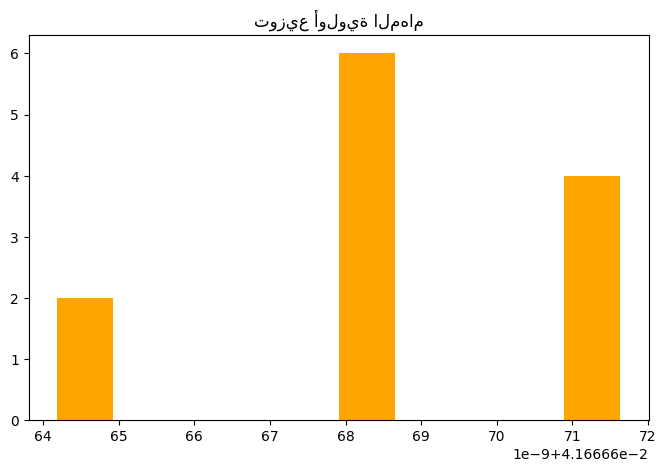

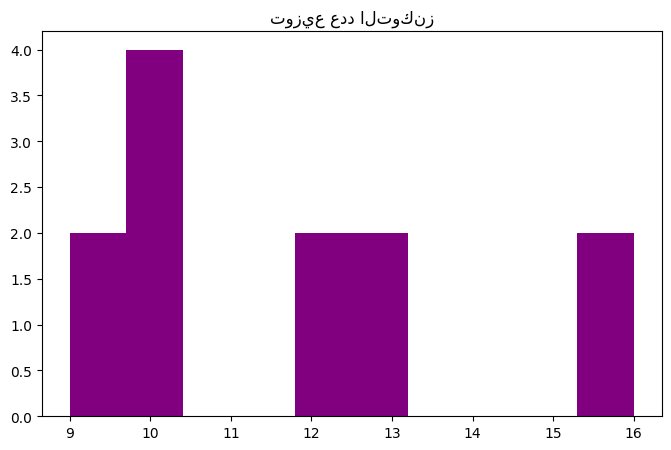

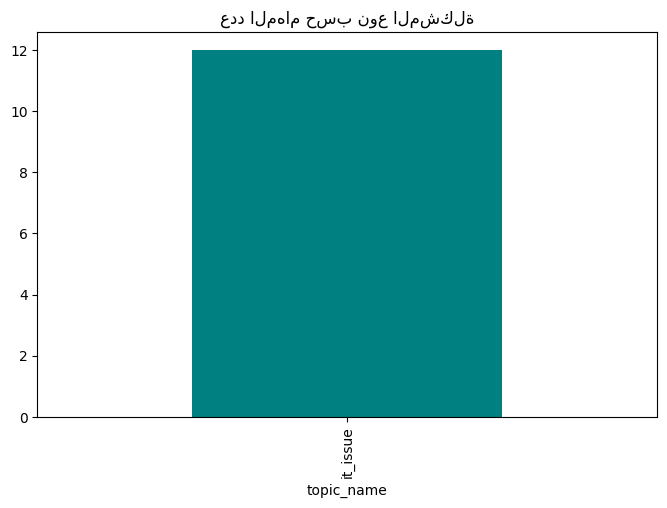

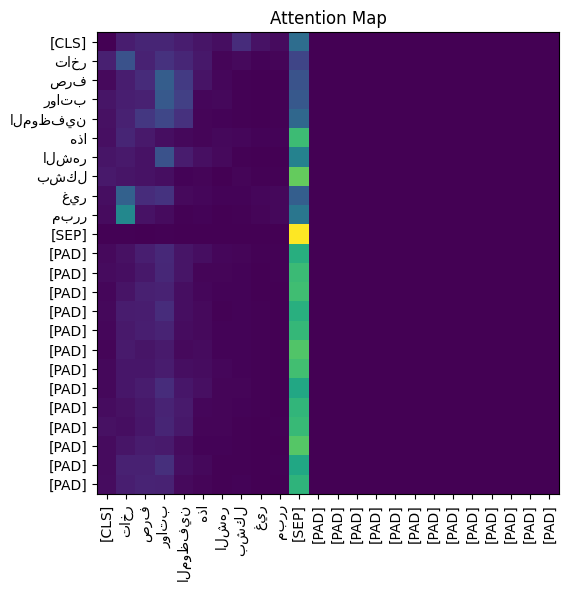

الكلمات الأصلية: ['النظام', 'الداخلي', 'للموارد', 'البشريه', 'لا', 'يستجيب', 'عند', 'تسجيل', 'الاجازات']

Tokens:
[CLS] → كلمة None
النظام → كلمة 0
الداخلي → كلمة 1
للموا → كلمة 2
##رد → كلمة 2
البشريه → كلمة 3
لا → كلمة 4
يستجيب → كلمة 5
عند → كلمة 6
تسجيل → كلمة 7
الاج → كلمة 8
##از → كلمة 8
##ات → كلمة 8
[SEP] → كلمة None

Clitics:
- للموارد
نتائج البحث الأولية:
- تكرار انقطاع نظام البريد الإلكتروني يؤثر على التواصل بين الفرق
- سير العمل في قسم العمليات غير منظم وتوجد مهام بدون مسؤول واضح
- النظام الداخلي للموارد البشرية لا يستجيب عند تسجيل الإجازات

أفضل نتيجة بعد إعادة الترتيب:
-2.48 → النظام الداخلي للموارد البشرية لا يستجيب عند تسجيل الإجازات
-3.72 → سير العمل في قسم العمليات غير منظم وتوجد مهام بدون مسؤول واضح
-6.18 → تكرار انقطاع نظام البريد الإلكتروني يؤثر على التواصل بين الفرق
===== التقرير النهائي =====
عدد المهام: 12
السعودية: 2
قصيرة: 0
طويلة: 12
لا توجد أخطاء مسجلة
فترات الثقة: 0.50 - 0.87


In [ ]:
add_task("تأخر صرف رواتب الموظفين هذا الشهر بشكل غير مبرر")
add_task("النظام الداخلي للموارد البشرية لا يستجيب عند تسجيل الإجازات")
add_task("تكرار انقطاع نظام البريد الإلكتروني يؤثر على التواصل بين الفرق")
add_task("يوجد تضارب في القرارات بين الإدارة العليا ومدير القسم")
add_task("سير العمل في قسم العمليات غير منظم وتوجد مهام بدون مسؤول واضح")
add_task("وش وضع نظام الحضور والانصراف؟ الموظفين يشتكون من الأخطاء المتكررة")

show_tasks()
dashboard()

analyze_task_attention(0)
analyze_task_words(1)

search_tasks("مشكلة في نظام الموارد البشرية")

final_report()